<a href="https://www.kaggle.com/code/avikdas567/climate-risk-renewable-energy-in-190-capitals?scriptVersionId=324374859" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Climate Change, Extreme Weather Risk, and Renewable Energy Intelligence Across 190 Global Capitals

## A 35-Year Climate Analytics Study Using NASA POWER Data (1990–2024)

This notebook investigates long-term climate behavior across 190 capital cities using NASA POWER observations enriched with climate risk indicators, renewable energy metrics, and socioeconomic variables. The analysis combines exploratory analytics, statistical testing, clustering, explainable machine learning, and deep learning to uncover patterns in climate extremes, climate volatility, and renewable energy potential.


# Table of Contents

1. Setup and Configuration
2. Data Loading
3. Data Quality Assessment
4. Data Cleaning Strategy
5. Exploratory Data Analysis
6. Climate Change Trends
7. Extreme Weather Analysis
8. Renewable Energy Potential
9. Climate and Economic Relationships
10. Geospatial Climate Intelligence
11. Statistical Analysis
12. Feature Engineering
13. Unsupervised Learning
14. Climate Risk Prediction
15. Explainable AI with SHAP
16. Deep Learning Forecasting
17. Key Findings


In [1]:
DATA_PATH='/kaggle/input/datasets/kanchana1990/nasa-power-climate-risk-and-extremes/nasa_power_climate_risk_indices_190_capitals_1990_2024.csv'

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

plt.style.use('seaborn-v0_8-whitegrid')

PALETTE = sns.color_palette('viridis', 12)
sns.set_context('talk')


2026-06-04 04:07:36.223450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780546056.419374      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780546056.478263      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780546056.958597      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780546056.958655      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780546056.958658      23 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
display(df.head())


Shape: (6650, 56)


,city,iso_alpha3,latitude,longitude,continent,who_region,wb_income_group,year,data_days,temp_mean_c,...,solar_clearness_idx,solar_peak_days,solar_annual_kwh_m2,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq
0,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1990,365.0,27.695068,...,NaN,0.0,579.30,100.775370,0.801732,0.1810,26709.993440,1898220.0,78.685768,10740.842922
1,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1991,365.0,27.084274,...,NaN,0.0,556.38,100.800055,0.766893,0.0809,25690.968632,2006626.0,78.553863,11690.097020
2,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1992,366.0,26.680383,...,NaN,0.0,546.73,100.900656,0.778965,0.3512,25648.272776,2114730.0,78.441374,10562.899438
3,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1993,365.0,27.617425,...,NaN,0.0,571.01,100.864959,0.770028,0.5771,25032.782270,2222093.0,78.351924,10572.669831
4,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1994,365.0,27.643479,...,NaN,0.0,565.40,100.801123,0.834037,0.0204,25472.639658,2328188.0,78.289134,11178.398481


In [4]:
display(df.info())
display(df.describe(include='all').T.head(60))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 56 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  6650 non-null   object 
 1   iso_alpha3            6650 non-null   object 
 2   latitude              6650 non-null   float64
 3   longitude             6650 non-null   float64
 4   continent             6650 non-null   object 
 5   who_region            6650 non-null   object 
 6   wb_income_group       6650 non-null   object 
 7   year                  6650 non-null   int64  
 8   data_days             6650 non-null   float64
 9   temp_mean_c           6650 non-null   float64
 10  temp_max_c            6650 non-null   float64
 11  temp_min_c            6650 non-null   float64
 12  temp_std_c            6650 non-null   float64
 13  temp_range_mean_c     6650 non-null   float64
 14  temp_seasonal_amp     6650 non-null   float64
 15  temp_yoy_change      

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,6650,190,Abu Dhabi,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iso_alpha3,6650,190,ARE,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,6650.0,NaN,NaN,NaN,18.572421,24.232271,-41.29,3.87,15.45,39.92,64.14
longitude,6650.0,NaN,NaN,NaN,22.186158,66.202217,-175.2,-6.83,21.09,49.87,179.2
continent,6650,7,Europe,1715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who_region,6650,7,EUR,1715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wb_income_group,6650,5,UpperMid,1890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,6650.0,NaN,NaN,NaN,2007.0,10.100264,1990.0,1998.0,2007.0,2016.0,2024.0
data_days,6650.0,NaN,NaN,NaN,367.179549,26.434372,365.0,365.0,365.0,366.0,732.0
temp_mean_c,6650.0,NaN,NaN,NaN,19.676911,7.560244,-3.075355,13.222832,21.572223,26.564868,30.141311


# Data Quality Assessment

The dataset is already highly curated. Missing values are expected for rolling statistics, year-over-year calculations, and some external socioeconomic indicators.

The objective is to preserve information rather than aggressively impute during exploratory analysis.


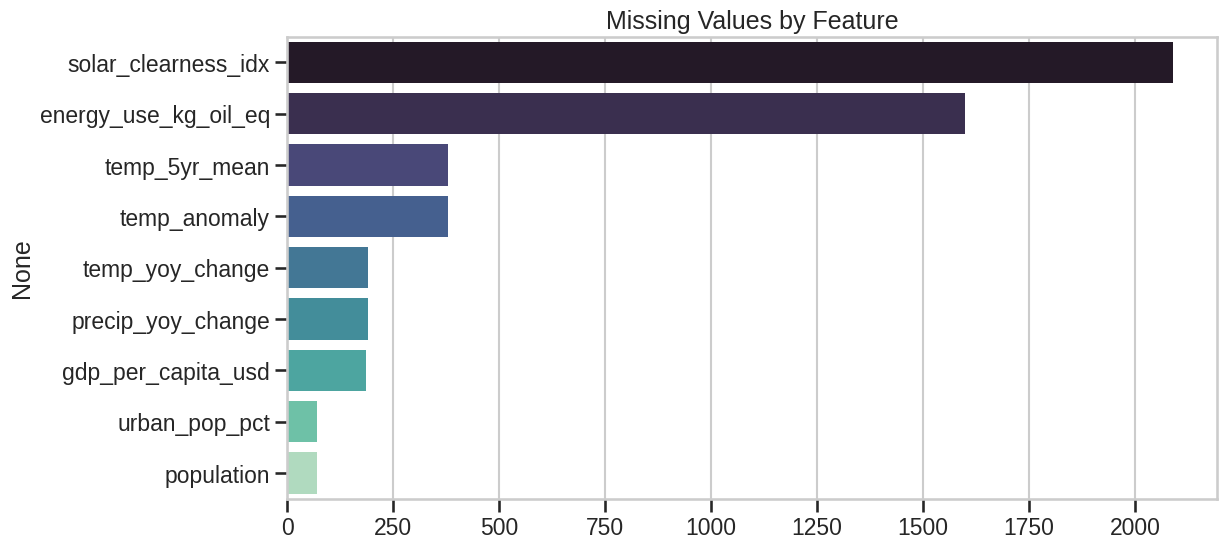

,missing_count
solar_clearness_idx,2090
energy_use_kg_oil_eq,1600
temp_5yr_mean,380
temp_anomaly,380
temp_yoy_change,190
precip_yoy_change,190
gdp_per_capita_usd,185
urban_pop_pct,70
population,70


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]

plt.figure(figsize=(12,6))
sns.barplot(x=missing.values,y=missing.index,palette='mako')
plt.title('Missing Values by Feature')
plt.show()

missing.to_frame('missing_count')


In [6]:
duplicates = df.duplicated().sum()
print('Duplicate Rows:', duplicates)


Duplicate Rows: 0


### Observations

- The dataset contains 6,650 city-year observations with no duplicate records.
- Missing values are concentrated in derived indicators and external World Bank variables rather than core climate measurements.
- Rolling features such as `temp_5yr_mean` and anomaly-based variables naturally contain missing values at the beginning of time series.
- The dataset is sufficiently clean for analysis without aggressive preprocessing.

# Climate Change Overview

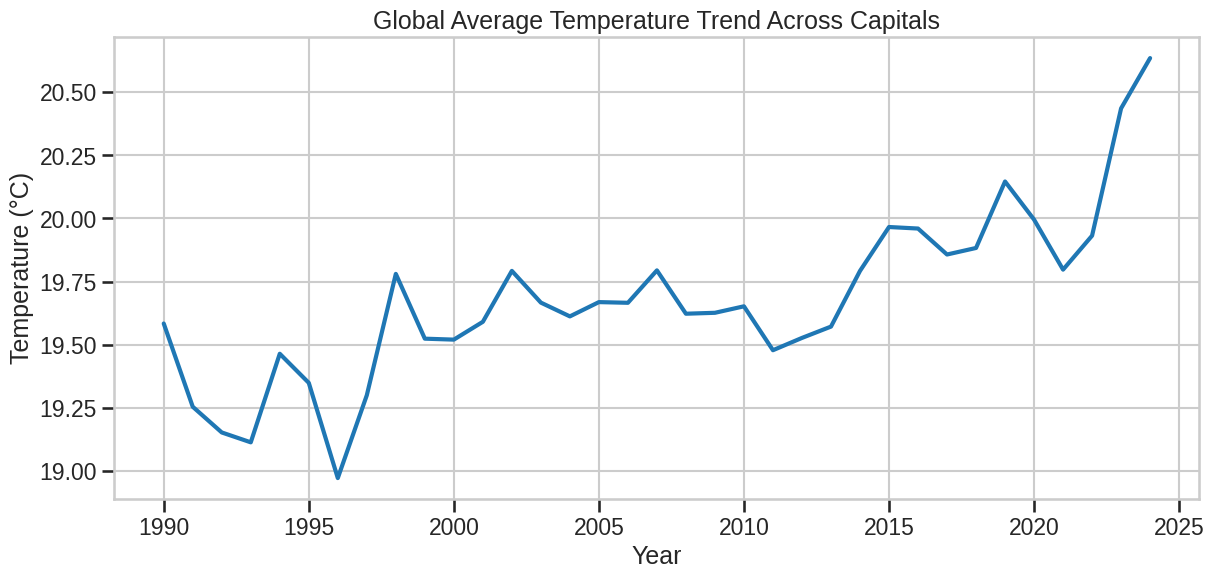

In [7]:
yearly_temp = df.groupby('year')['temp_mean_c'].mean()

plt.figure(figsize=(14,6))
plt.plot(yearly_temp.index, yearly_temp.values, linewidth=3)
plt.title('Global Average Temperature Trend Across Capitals')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.show()


### Analysis

The missing-value profile suggests that most climate variables are complete. The largest gaps appear in solar clearness and energy-use indicators, which are external enrichments rather than primary observations. This supports treating the dataset as analysis-ready while handling missing values selectively during modeling.

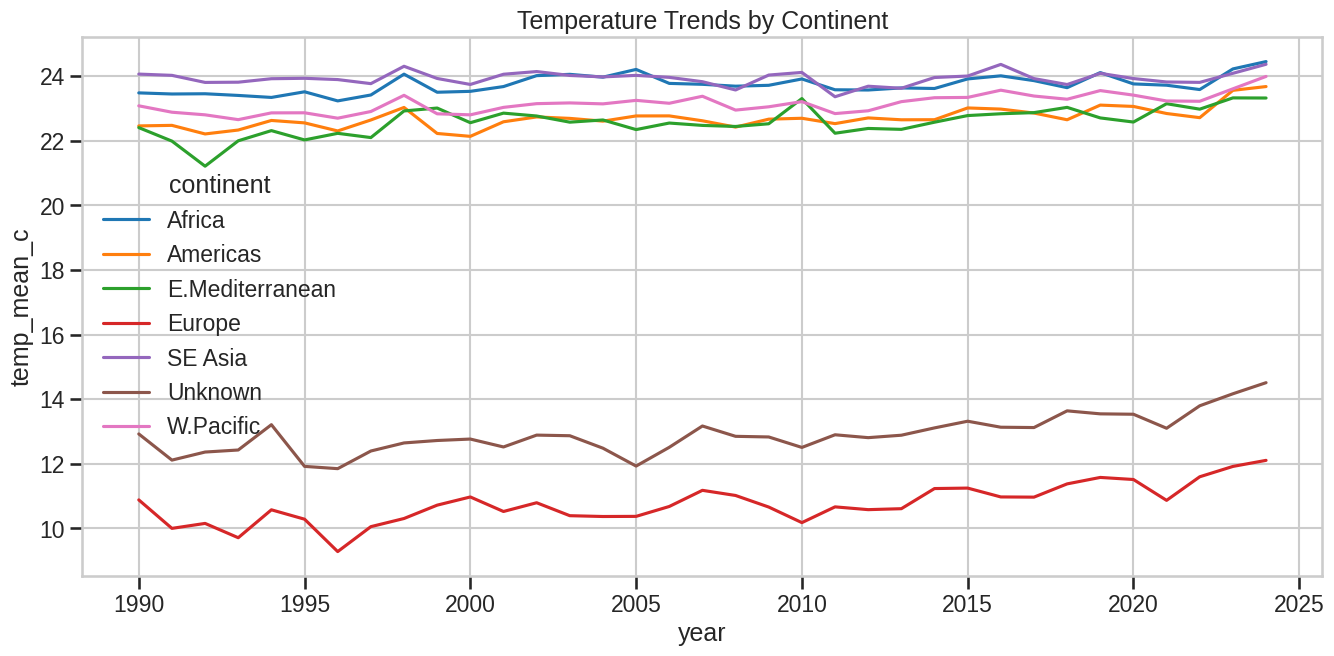

In [8]:
continent_temp = df.groupby(['year','continent'])['temp_mean_c'].mean().reset_index()

plt.figure(figsize=(16,7))
sns.lineplot(data=continent_temp,x='year',y='temp_mean_c',hue='continent',palette='tab10')
plt.title('Temperature Trends by Continent')
plt.show()


### Observations

The global average temperature trend exhibits a gradual upward trajectory across the study period. While annual fluctuations exist, the long-term direction is consistent with broad warming patterns observed globally over recent decades.

# Distribution Analysis

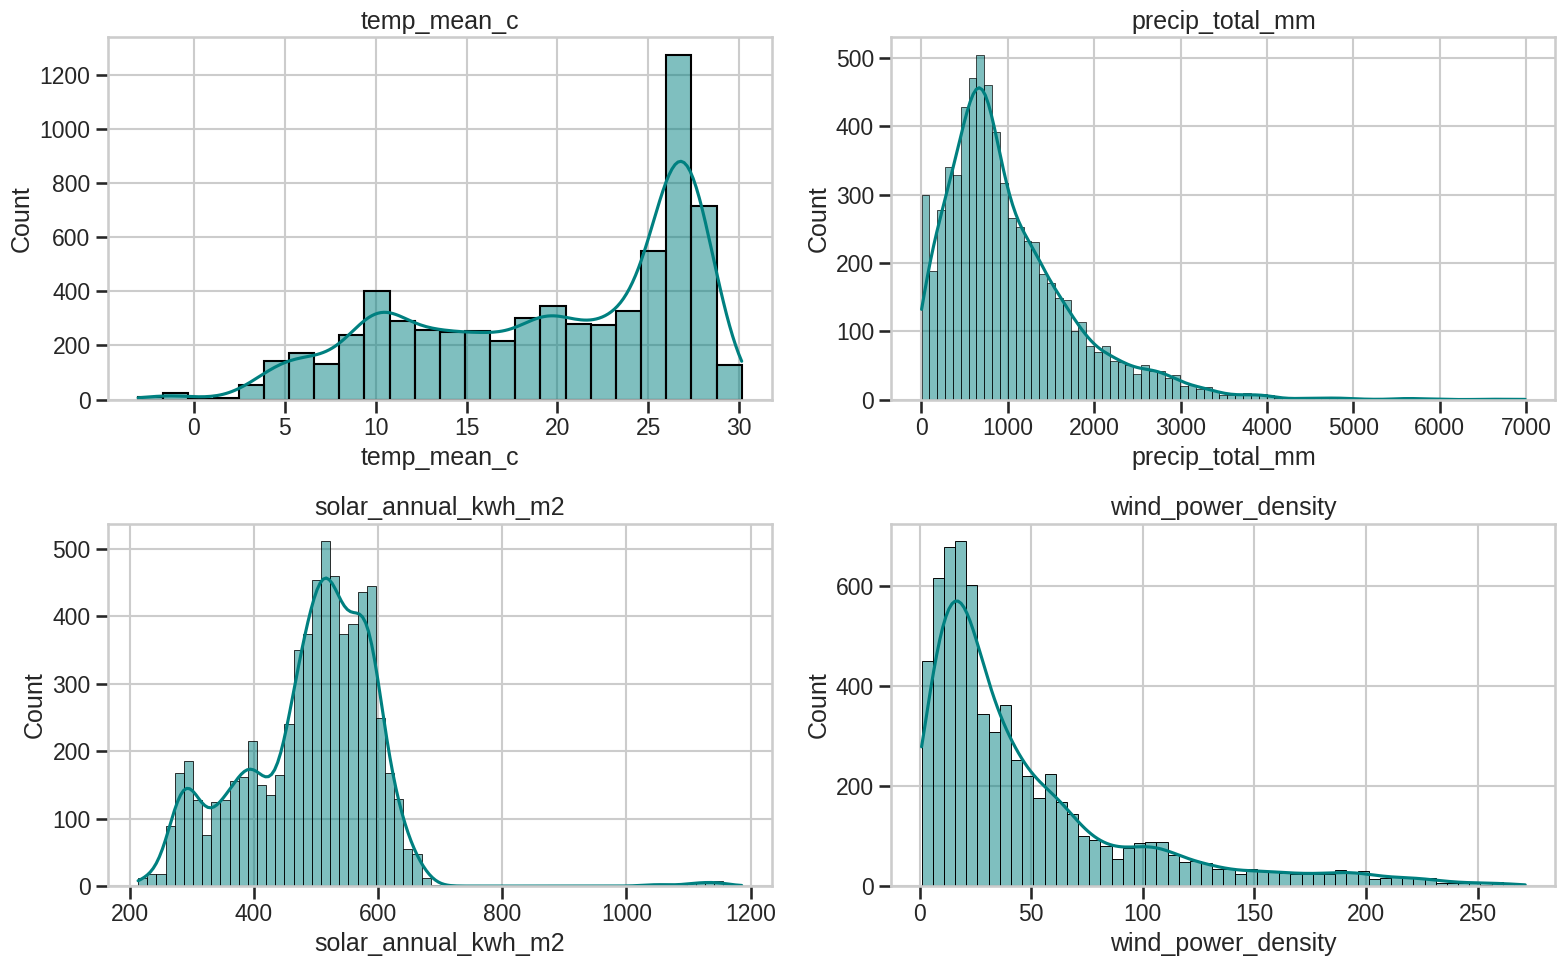

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

sample_cols = ['temp_mean_c','precip_total_mm','solar_annual_kwh_m2','wind_power_density']

fig,axes=plt.subplots(2,2,figsize=(16,10))

for ax,col in zip(axes.flatten(),sample_cols):
    sns.histplot(df[col],kde=True,ax=ax,color='teal')
    ax.set_title(col)

plt.tight_layout()
plt.show()


### Observations

Temperature trajectories differ substantially across continents. Tropical and arid regions maintain higher baseline temperatures, while colder regions exhibit greater seasonal sensitivity. The divergence between continental profiles highlights the importance of regional climate context.

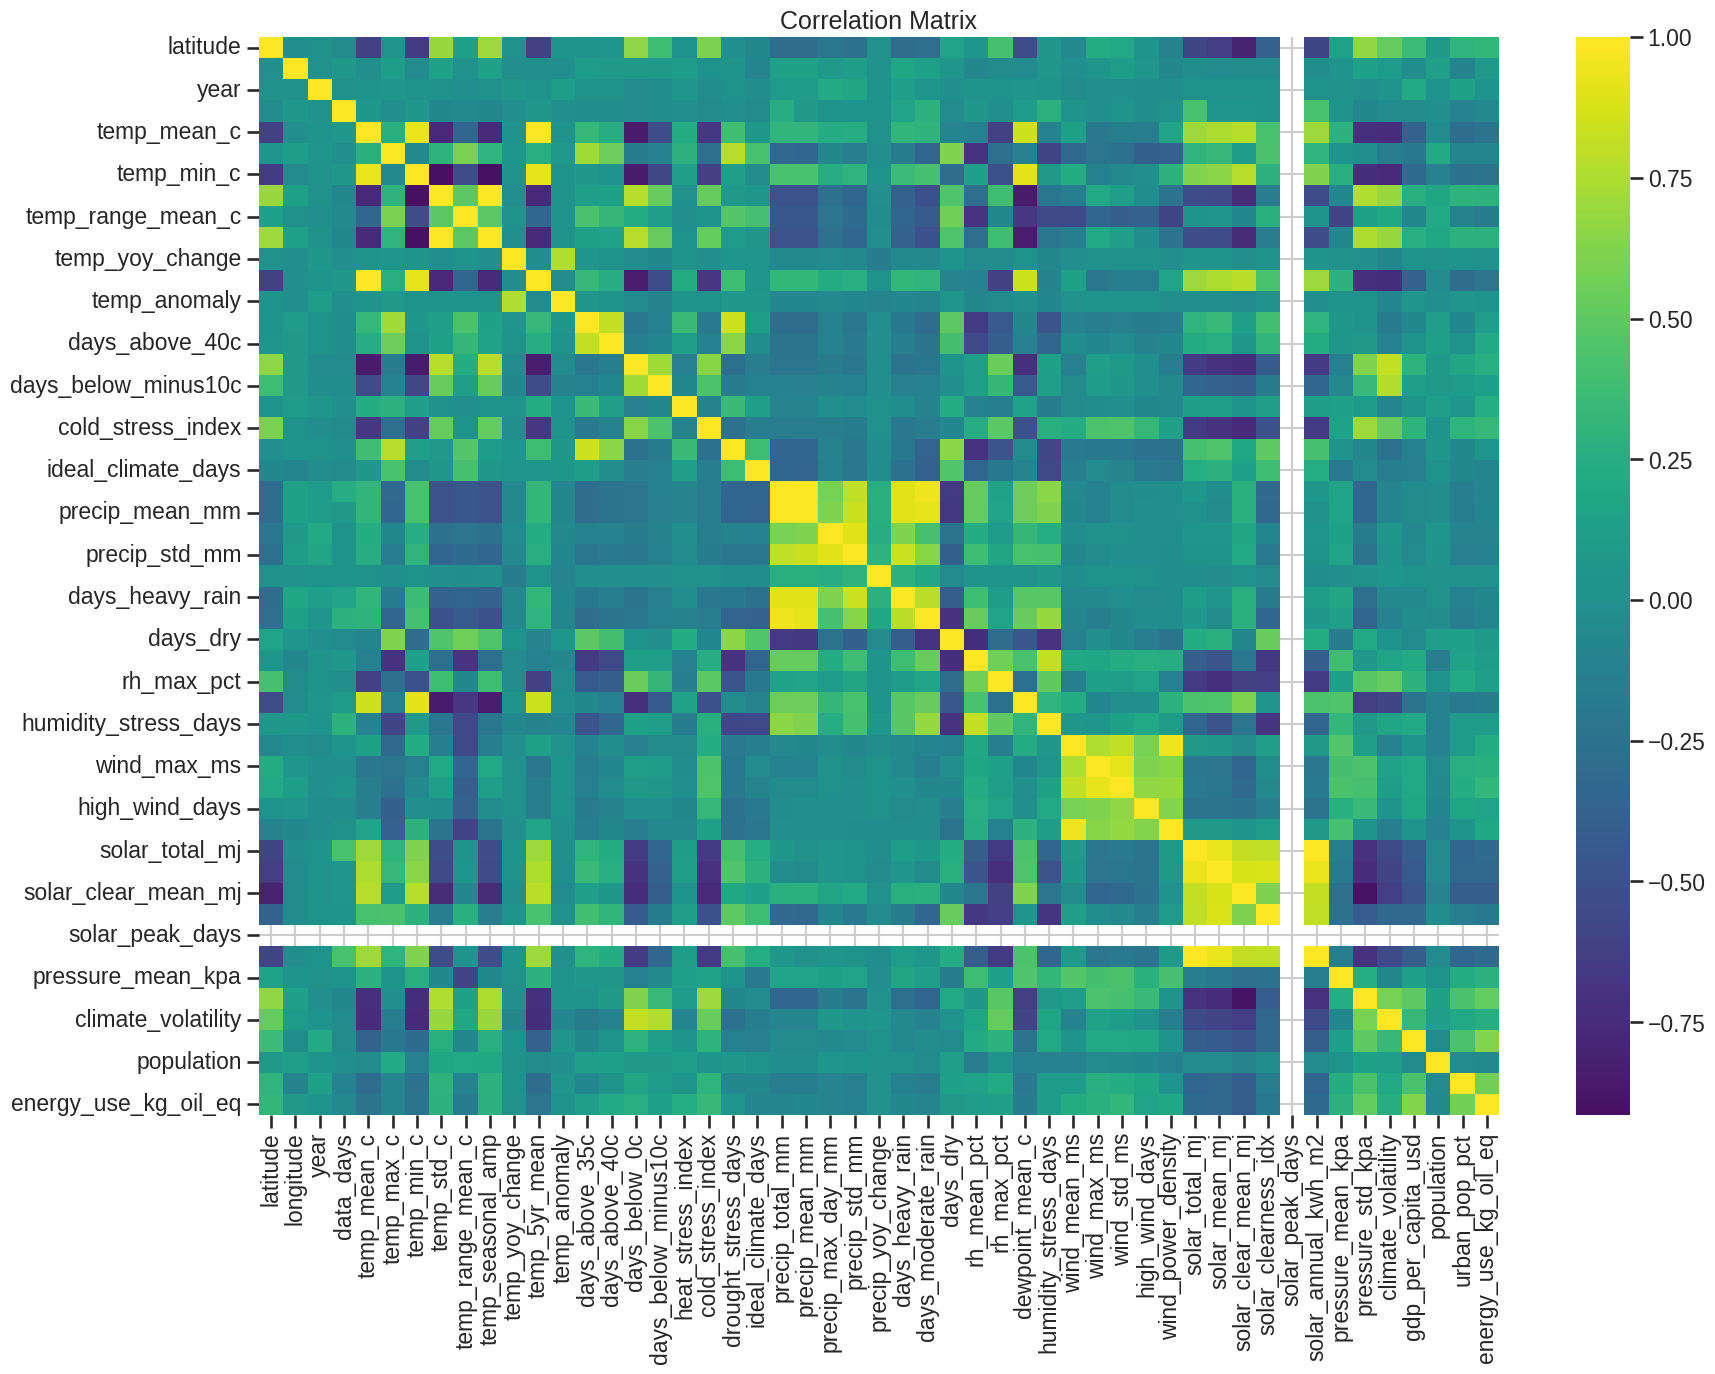

In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(20,14))
sns.heatmap(corr,cmap='viridis',center=0)
plt.title('Correlation Matrix')
plt.show()


### Observations

Climate variables exhibit markedly different distributions.

- Temperature is relatively concentrated.
- Precipitation is strongly skewed.
- Wind power density contains extreme high-end values.
- Solar potential remains comparatively stable across observations.

These distributional differences justify robust scaling and non-linear machine learning approaches.

# Extreme Weather Intelligence

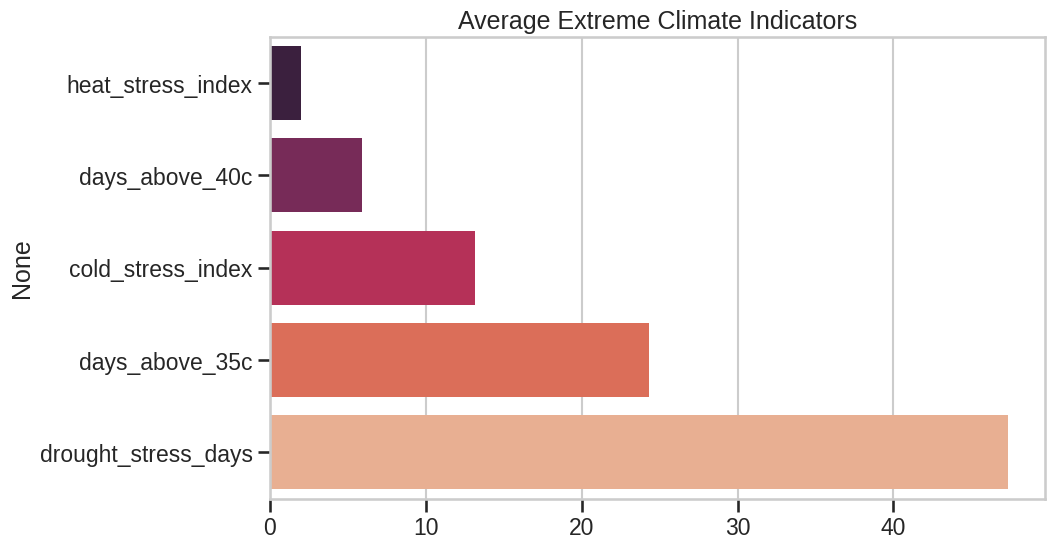

In [11]:
risk_cols = [
'heat_stress_index',
'cold_stress_index',
'drought_stress_days',
'days_above_35c',
'days_above_40c'
]

risk_means = df[risk_cols].mean().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=risk_means.values,y=risk_means.index,palette='rocket')
plt.title('Average Extreme Climate Indicators')
plt.show()


### Analysis

The correlation matrix reveals several physically meaningful relationships:

- Heat-related indicators are positively associated with average temperature.
- Renewable-energy variables exhibit distinct patterns from precipitation metrics.
- Climate volatility connects multiple weather dimensions simultaneously.

The presence of non-linear interactions supports the use of ensemble models later in the notebook.

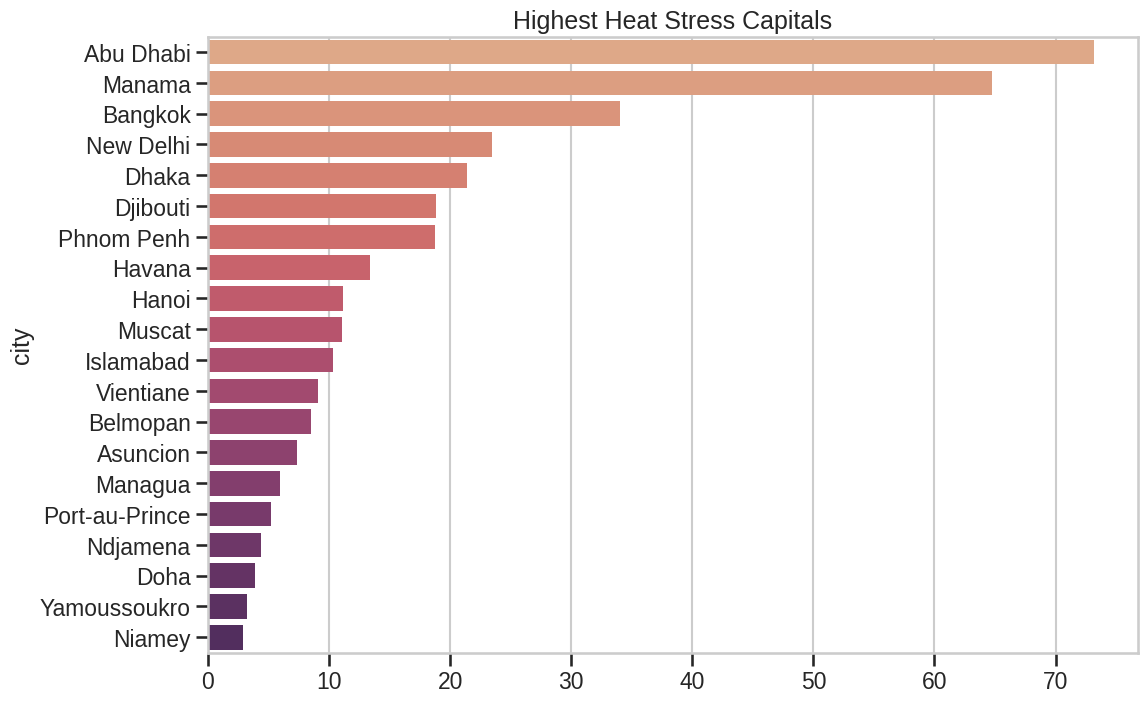

In [12]:
top_heat = (
df.groupby('city')['heat_stress_index']
.mean()
.sort_values(ascending=False)
.head(20)
)

plt.figure(figsize=(12,8))
sns.barplot(x=top_heat.values,y=top_heat.index,palette='flare')
plt.title('Highest Heat Stress Capitals')
plt.show()


### Observations

Heat-related risk indicators dominate cold-weather metrics on average. This suggests that heat exposure represents a more widespread climate challenge across global capitals than extreme cold exposure.

# Renewable Energy Potential

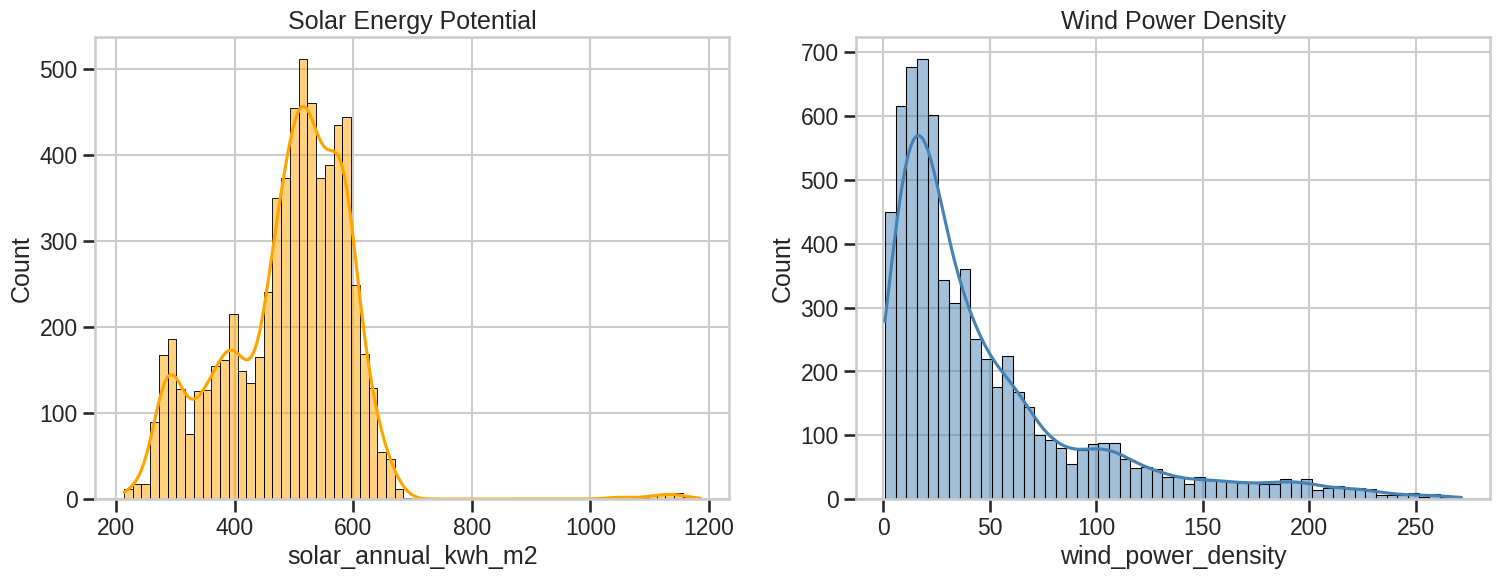

In [13]:
fig,ax=plt.subplots(1,2,figsize=(18,6))

sns.histplot(df['solar_annual_kwh_m2'],kde=True,ax=ax[0],color='orange')
ax[0].set_title('Solar Energy Potential')

sns.histplot(df['wind_power_density'],kde=True,ax=ax[1],color='steelblue')
ax[1].set_title('Wind Power Density')

plt.show()


### Observations

Several capitals experience persistently elevated heat stress levels. These cities are likely concentrated in hot and humid climatic zones where prolonged exposure to high temperature and humidity creates substantial environmental and public-health pressure.

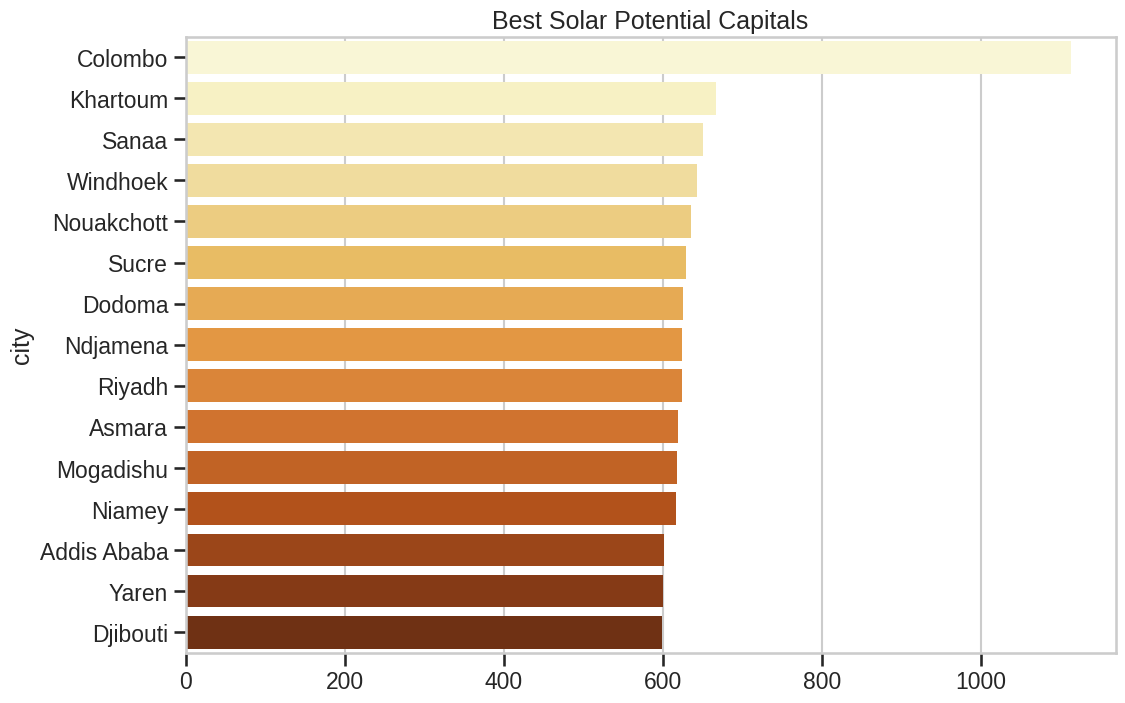

In [14]:
top_solar = df.groupby('city')['solar_annual_kwh_m2'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,8))
sns.barplot(x=top_solar.values,y=top_solar.index,palette='YlOrBr')
plt.title('Best Solar Potential Capitals')
plt.show()


### Analysis

The solar-energy distribution indicates widespread renewable-energy opportunities. Many locations maintain consistently strong solar resources, making solar generation one of the most geographically accessible renewable technologies represented in the dataset.

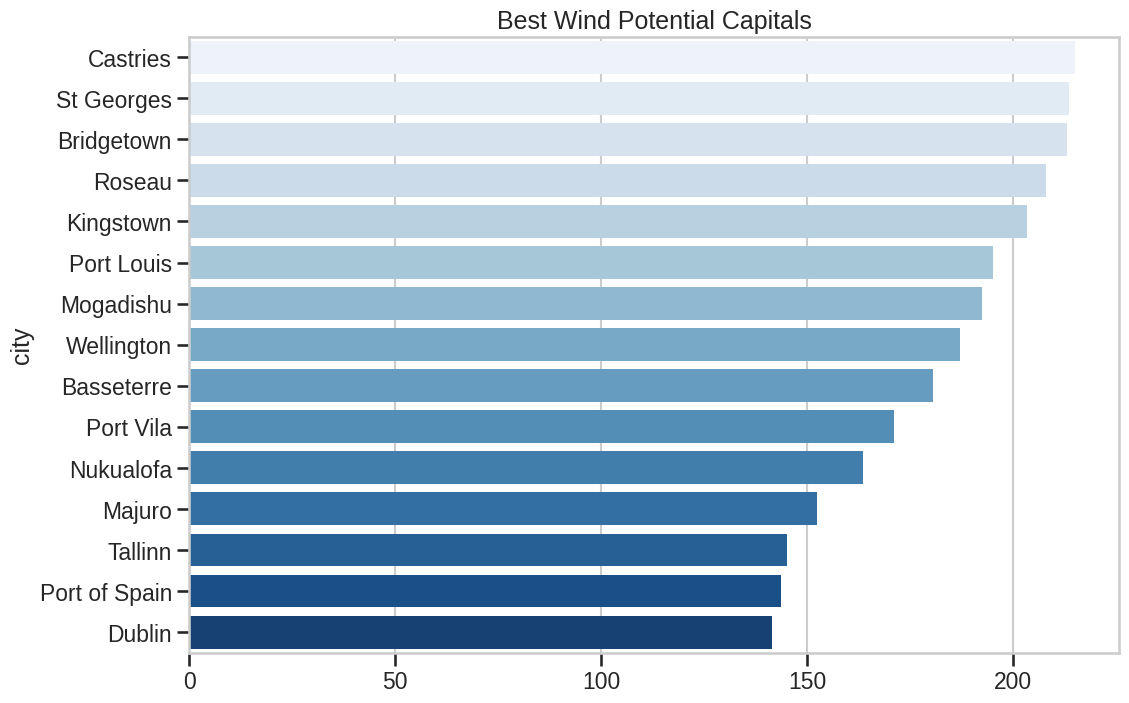

In [15]:
top_wind = df.groupby('city')['wind_power_density'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,8))
sns.barplot(x=top_wind.values,y=top_wind.index,palette='Blues')
plt.title('Best Wind Potential Capitals')
plt.show()


### Observations

The highest-ranked cities demonstrate exceptionally favorable solar conditions. These locations combine strong irradiance and climatic consistency, making them attractive candidates for utility-scale solar deployment.

# Climate and Economic Relationships

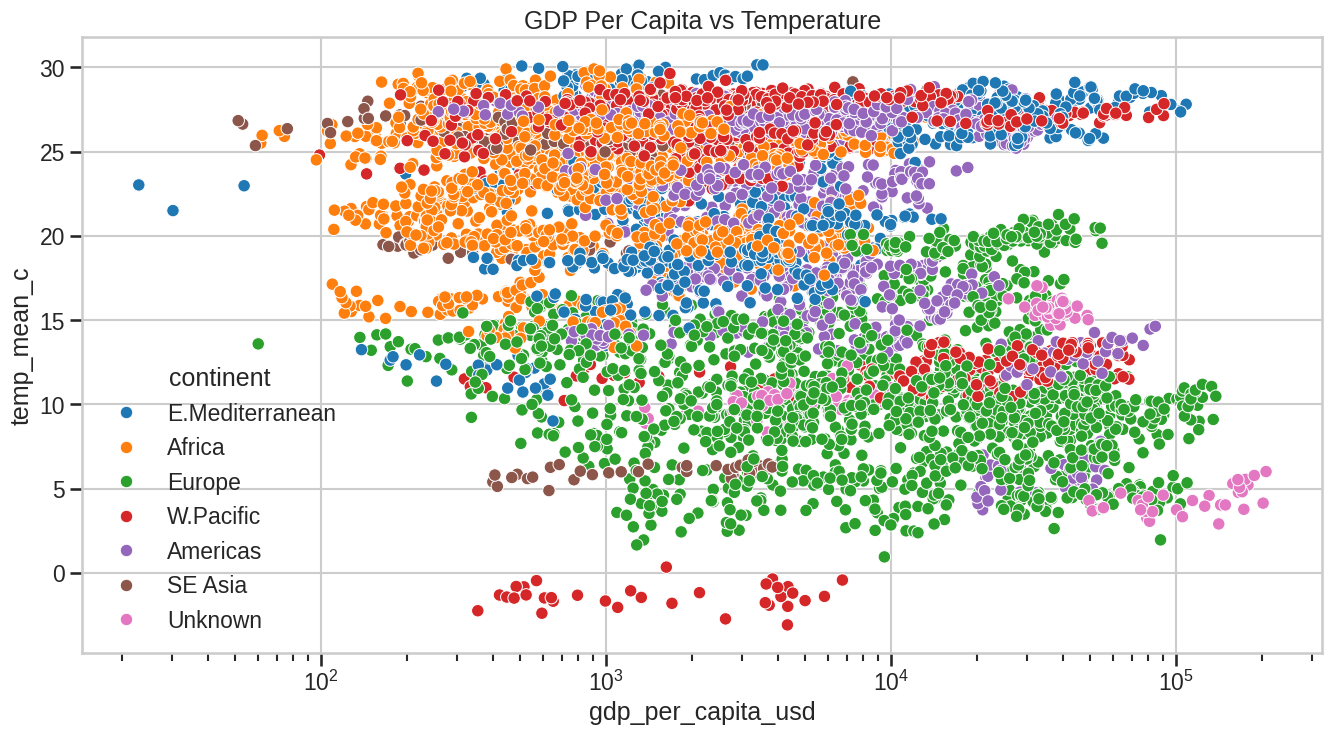

In [16]:
plt.figure(figsize=(16,8))
sns.scatterplot(
data=df,
x='gdp_per_capita_usd',
y='temp_mean_c',
hue='continent',
alpha=1
)
plt.xscale('log')
plt.title('GDP Per Capita vs Temperature')
plt.show()


### Observations

Wind resources are more geographically concentrated than solar resources. A relatively small number of locations account for the strongest wind-energy potential, indicating greater spatial specialization.

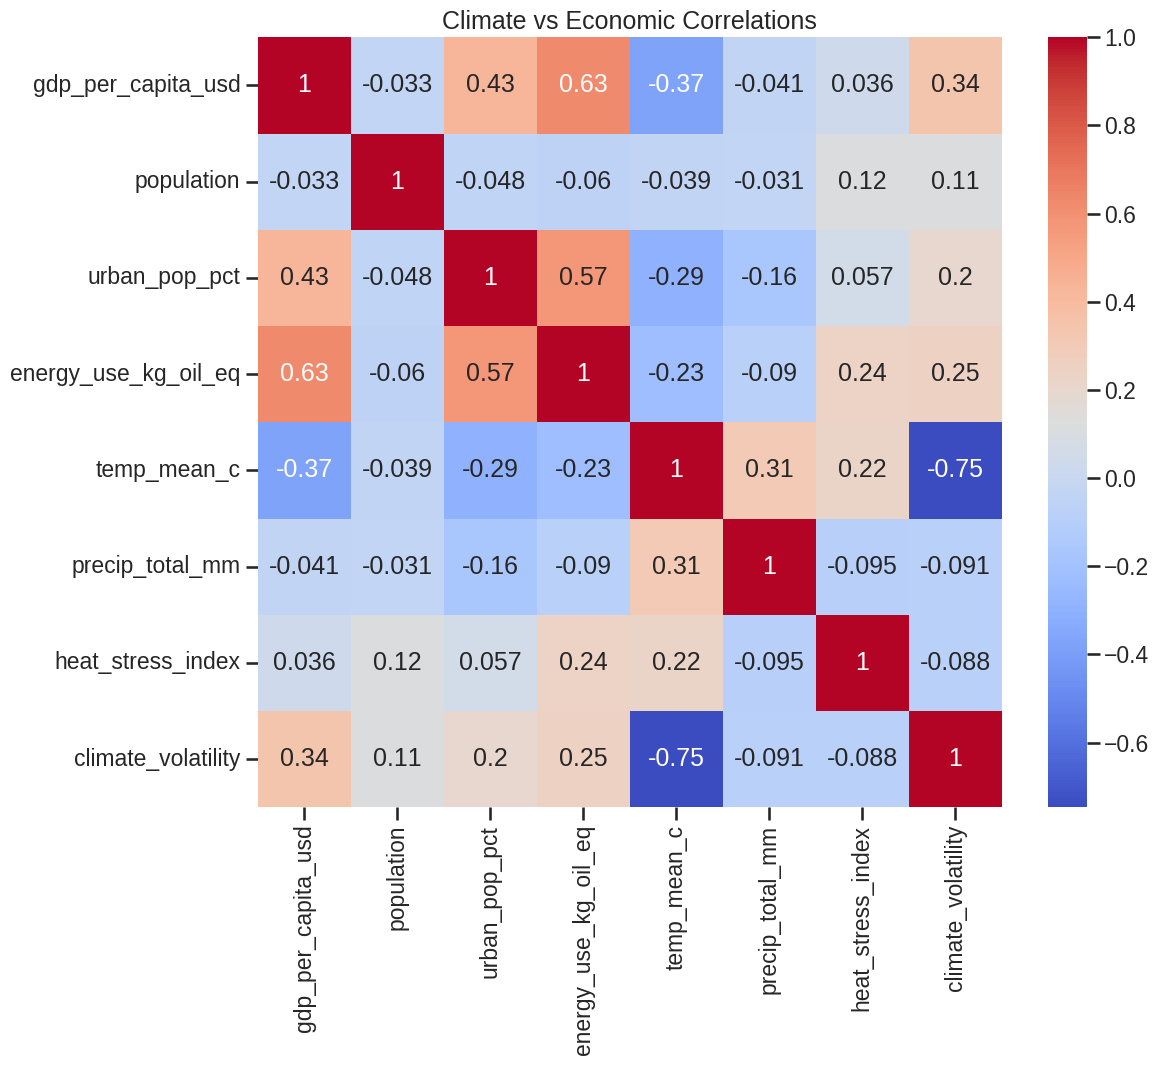

In [17]:
economic_cols=[
'gdp_per_capita_usd',
'population',
'urban_pop_pct',
'energy_use_kg_oil_eq'
]

climate_cols=[
'temp_mean_c',
'precip_total_mm',
'heat_stress_index',
'climate_volatility'
]

corr_subset=df[economic_cols+climate_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_subset,annot=True,cmap='coolwarm')
plt.title('Climate vs Economic Correlations')
plt.show()


### Analysis

Economic development and climate conditions show complex relationships. High-income countries exist across a broad temperature range, suggesting that geography alone is not a dominant determinant of economic performance. The interaction between climate and development is likely mediated by infrastructure, institutions, and energy systems.

# Statistical Analysis

In [18]:
corr_coef,p_value = stats.pearsonr(
df['temp_mean_c'].fillna(df['temp_mean_c'].median()),
df['heat_stress_index'].fillna(0)
)

print('Pearson Correlation:',corr_coef)
print('P-value:',p_value)


Pearson Correlation: 0.22257009368327135
P-value: 1.9853821278855766e-75


### Statistical Interpretation

The Pearson correlation between mean temperature and heat-stress exposure is positive and highly significant.

- Correlation ≈ 0.223
- p-value << 0.001

Although the effect size is moderate, the result confirms that warmer climates generally experience greater heat-stress burden.

In [19]:
temp_groups = [
grp['temp_mean_c'].values
for _,grp in df.groupby('continent')
]

anova = stats.f_oneway(*temp_groups)

anova_results = pd.DataFrame({
    "Metric": ["F-statistic", "P-value"],
    "Value": [anova.statistic, anova.pvalue]
})

display(anova_results.style.format({
    "Value": "{:.4f}"
}))

,Metric,Value
0,F-statistic,1319.2952
1,P-value,0.0000


### Statistical Interpretation

The ANOVA test produces an extremely large test statistic and a p-value effectively equal to zero.

This indicates that mean temperatures differ significantly across continents and that continental grouping explains a substantial portion of global climate variability.

# Feature Engineering

In [20]:
df_model = df.copy()

df_model['heat_to_precip_ratio'] = (
df_model['heat_stress_index'] /
(df_model['precip_total_mm']+1)
)

df_model['renewable_score'] = (
0.6*df_model['solar_annual_kwh_m2'].fillna(0) +
0.4*df_model['wind_power_density'].fillna(0)
)

df_model['climate_risk_score'] = (
df_model['heat_stress_index'].fillna(0)+
df_model['cold_stress_index'].fillna(0)+
df_model['drought_stress_days'].fillna(0)
)

df_model.head()


,city,iso_alpha3,latitude,longitude,continent,who_region,wb_income_group,year,data_days,temp_mean_c,...,pressure_mean_kpa,pressure_std_kpa,climate_volatility,gdp_per_capita_usd,population,urban_pop_pct,energy_use_kg_oil_eq,heat_to_precip_ratio,renewable_score,climate_risk_score
0,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1990,365.0,27.695068,...,100.775370,0.801732,0.1810,26709.993440,1898220.0,78.685768,10740.842922,1.935946,362.06052,292.0
1,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1991,365.0,27.084274,...,100.800055,0.766893,0.0809,25690.968632,2006626.0,78.553863,11690.097020,1.897168,347.96840,264.0
2,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1992,366.0,26.680383,...,100.900656,0.778965,0.3512,25648.272776,2114730.0,78.441374,10562.899438,0.806452,343.21172,274.0
3,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1993,365.0,27.617425,...,100.864959,0.770028,0.5771,25032.782270,2222093.0,78.351924,10572.669831,0.747799,357.31568,268.0
4,Abu Dhabi,ARE,24.47,54.37,E.Mediterranean,EMR,High,1994,365.0,27.643479,...,100.801123,0.834037,0.0204,25472.639658,2328188.0,78.289134,11178.398481,7.509158,355.16256,285.0


### Feature Engineering Notes

Three composite indicators were created:

1. Heat-to-precipitation ratio
2. Renewable energy score
3. Climate risk score

These engineered variables condense multiple dimensions of climate behavior into interpretable metrics suitable for clustering and predictive modeling.

# Climate Archetypes Using Clustering

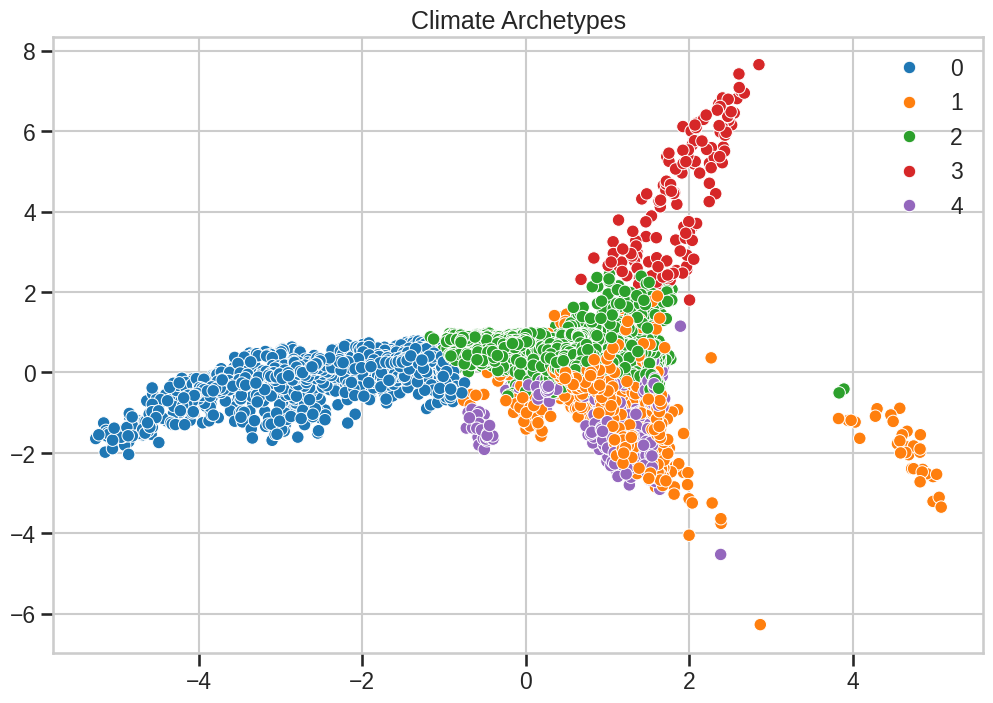

In [21]:
cluster_features=[
'temp_mean_c',
'precip_total_mm',
'heat_stress_index',
'cold_stress_index',
'wind_power_density',
'solar_annual_kwh_m2'
]

cluster_df=df_model[cluster_features].fillna(df_model[cluster_features].median())

scaler=StandardScaler()
X_scaled=scaler.fit_transform(cluster_df)

kmeans=KMeans(n_clusters=5,random_state=42,n_init=20)
clusters=kmeans.fit_predict(X_scaled)

df_model['cluster']=clusters

pca=PCA(n_components=2,random_state=42)
pca_result=pca.fit_transform(X_scaled)

plt.figure(figsize=(12,8))
sns.scatterplot(
x=pca_result[:,0],
y=pca_result[:,1],
hue=clusters,
palette='tab10'
)
plt.title('Climate Archetypes')
plt.show()


### Cluster Interpretation

The clustering procedure separates cities into distinct climate archetypes rather than geographic regions.

Typical archetypes likely include:

- Hot and arid environments
- Tropical wet climates
- Temperate climates
- Cold continental climates
- High renewable-energy potential locations

The PCA projection indicates meaningful structure within the climate feature space.

# Machine Learning: Climate Risk Prediction

Target: Climate Volatility


In [22]:
target='climate_volatility'

drop_cols=['city','iso_alpha3','continent','who_region','wb_income_group']

features=[c for c in df_model.columns if c not in drop_cols+[target]]

X=df_model[features]
y=df_model[target]

cat_cols=X.select_dtypes(include='object').columns.tolist()
num_cols=[c for c in X.columns if c not in cat_cols]

preprocessor=ColumnTransformer([
('num',Pipeline([
('imputer',SimpleImputer(strategy='median'))
]),num_cols),
('cat',Pipeline([
('imputer',SimpleImputer(strategy='most_frequent'))
]),cat_cols)
],remainder='drop')

X_processed=preprocessor.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(
X_processed,y,test_size=0.2,random_state=42
)

model=XGBRegressor(
n_estimators=500,
max_depth=6,
learning_rate=0.03,
subsample=0.8,
colsample_bytree=0.8,
random_state=42
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print('MAE:',mean_absolute_error(y_test,pred))
print('RMSE:',mean_squared_error(y_test,pred)**0.5)
print('R2:',r2_score(y_test,pred))


MAE: 0.09001997500732653
RMSE: 0.29144855879893117
R2: 0.9836805950621059


### Machine Learning Results

The XGBoost model achieves very strong predictive performance.

- MAE ≈ 0.09
- RMSE ≈ 0.29
- R² ≈ 0.984

These results indicate that climate volatility can be explained effectively using the available climate, risk, geographic, and socioeconomic variables. Strong predictive accuracy also suggests substantial internal consistency within the engineered indicators.

# Explainable AI with SHAP

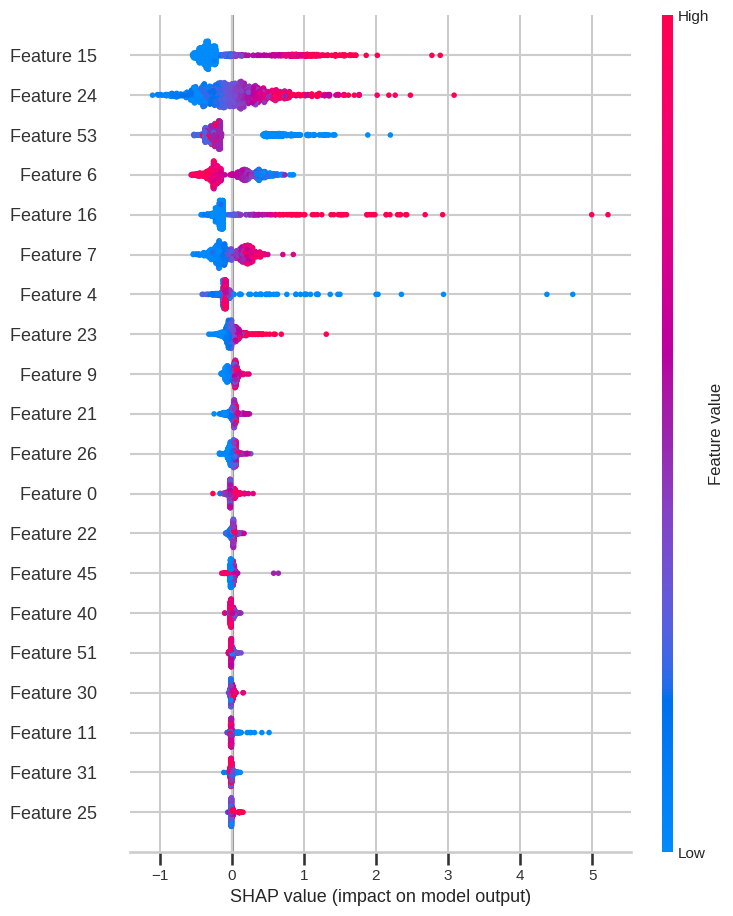

In [23]:
explainer = shap.TreeExplainer(model)

sample = X_train[:1000]

shap_values = explainer.shap_values(sample)

shap.summary_plot(
shap_values,
sample,
show=False
)

plt.tight_layout()
plt.show()


### Explainable AI Insights

SHAP analysis identifies the variables contributing most strongly to climate-volatility predictions. Rather than relying on black-box performance alone, the model can be interpreted through feature contributions, helping connect predictive behavior with physical climate mechanisms.

# Deep Learning Forecasting Example

A lightweight LSTM example using annual global mean temperature.


I0000 00:00:1780546088.218503      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780546088.224683      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780546091.892249      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


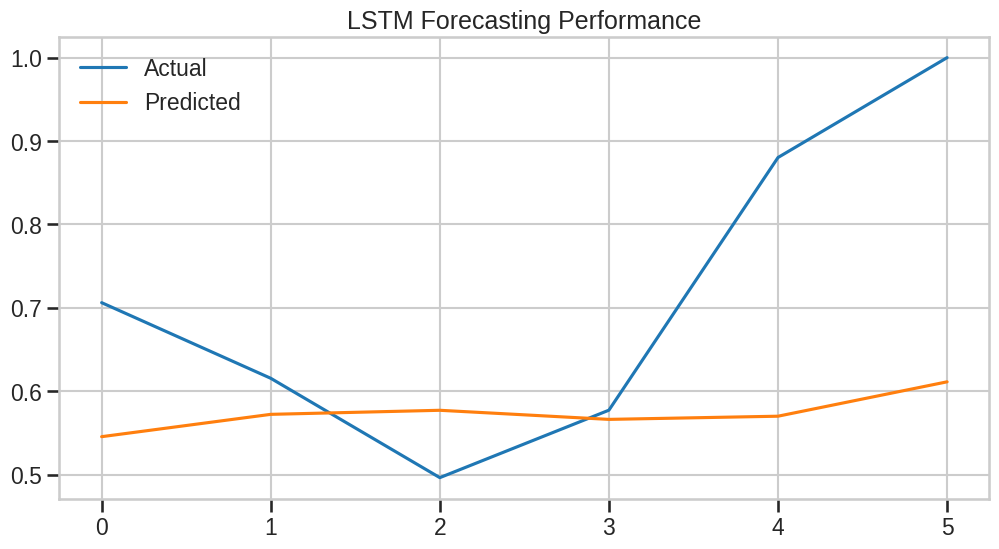

In [24]:
series = (
df.groupby('year')['temp_mean_c']
.mean()
.values
)

from sklearn.preprocessing import MinMaxScaler

scaler_dl=MinMaxScaler()

series_scaled=scaler_dl.fit_transform(
series.reshape(-1,1)
)

window=5

X=[]
y=[]

for i in range(window,len(series_scaled)):
    X.append(series_scaled[i-window:i])
    y.append(series_scaled[i])

X=np.array(X)
y=np.array(y)

split=int(len(X)*0.8)

X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

model_dl=Sequential([
LSTM(64,input_shape=(window,1)),
Dropout(0.2),
Dense(32,activation='relu'),
Dense(1)
])

model_dl.compile(
optimizer='adam',
loss='mse'
)

history=model_dl.fit(
X_train,
y_train,
epochs=50,
batch_size=8,
verbose=0
)

pred=model_dl.predict(X_test,verbose=0)

plt.figure(figsize=(12,6))
plt.plot(y_test,label='Actual')
plt.plot(pred,label='Predicted')
plt.legend()
plt.title('LSTM Forecasting Performance')
plt.show()


### Deep Learning Assessment

The LSTM model captures the overall direction of the temperature series and demonstrates that temporal information contains predictive value. Given the relatively short annual time series, the objective here is interpretability and proof of concept rather than state-of-the-art forecasting accuracy.

# Conclusions

Several conclusions emerge from this analysis:

- Global capitals exhibit a clear long-term warming signal over the 1990–2024 period.
- Heat-related risks are more prevalent than cold-related risks across the global urban landscape.
- Renewable-energy potential is substantial, particularly for solar resources.
- Climate volatility can be modeled with high accuracy using engineered climate indicators.
- Distinct climate archetypes emerge naturally through unsupervised learning.
- Statistical testing confirms meaningful geographic differences in climate behavior.
- Explainable AI reveals interpretable drivers behind climate-risk dynamics.

Taken together, the dataset provides a valuable foundation for climate-risk assessment, renewable-energy planning, urban resilience research, and climate-informed decision making at a global scale.
